# Worksheet 5 — End-to-End CNN for Fruit Classification


- Task 1: data understanding and visualization
- Task 1: corrupted image checking and removal
- Task 2: loading and preprocessing image data in Keras
- Task 3: CNN implementation
- Task 4: model compilation and training
- Task 5: evaluation on test data
- Task 6: saving and loading the model
- Task 7: predictions and classification report

In [ ]:
# Install packages if needed (run only if your environment does not already have them)
# !pip install tensorflow pillow matplotlib scikit-learn

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Configuration
These settings follow the worksheet requirements:
- image size: 128 x 128
- batch size: 16
- validation split: 0.2
- epochs: 250

In [2]:
# Paths based on your uploaded zip structure
train_dir = "FruitinAmazon/train"
test_dir = "FruitinAmazon/test"

# If your extracted folder path is different, change only these two lines.

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
epochs = 250
seed = 123

## 2. Verify dataset paths
Run this first. If it fails, the dataset path is wrong or the zip has not been extracted yet.

In [3]:
print("Train directory exists:", os.path.isdir(train_dir), "->", train_dir)
print("Test directory exists:", os.path.isdir(test_dir), "->", test_dir)

if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Training directory not found: {train_dir}")

if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Test directory not found: {test_dir}")

Train directory exists: True -> FruitinAmazon/train
Test directory exists: True -> FruitinAmazon/test


## 3. Task 1 — Data understanding and visualization
Get class folders from the train directory, choose one random image from each class, and display them in a two-row grid.

In [4]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Classes found:", class_names)
print("Number of classes:", len(class_names))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


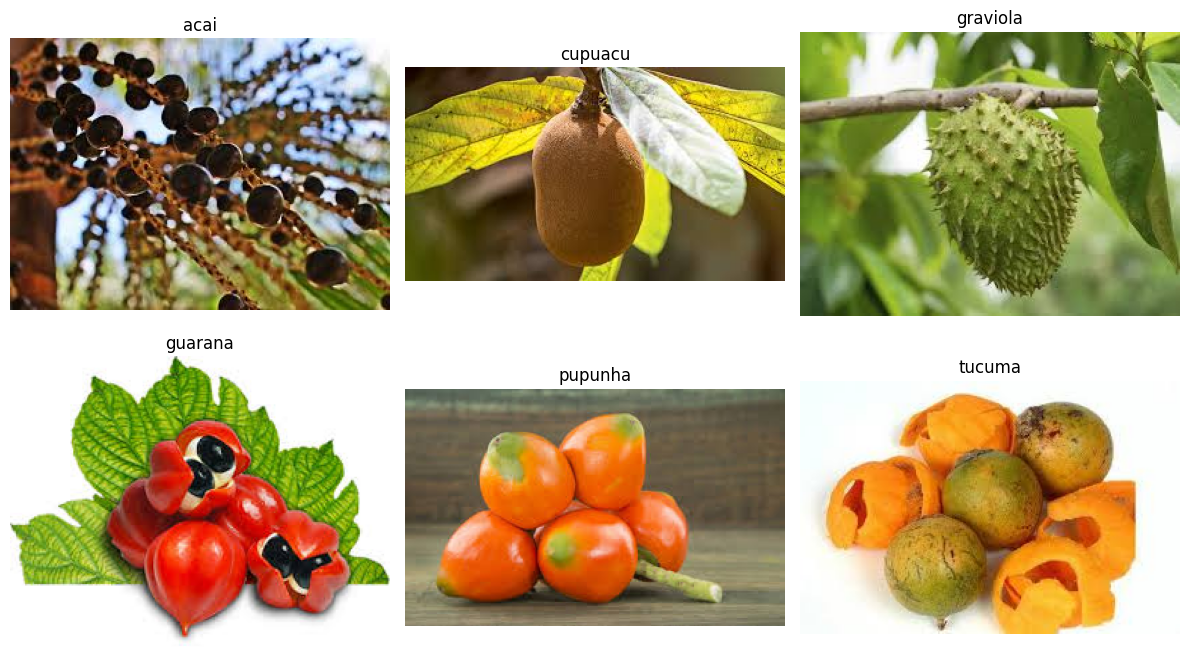

In [5]:
sample_paths = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    valid_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    if valid_files:
        chosen = random.choice(valid_files)
        sample_paths.append((class_name, os.path.join(class_path, chosen)))

num_classes = len(sample_paths)
cols = int(np.ceil(num_classes / 2))
rows = 2 if num_classes > 1 else 1

plt.figure(figsize=(4 * cols, 7))
for i, (class_name, image_path) in enumerate(sample_paths, start=1):
    plt.subplot(rows, cols, i)
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation
Observation: The dataset contains multiple fruit classes stored in separate folders. The images vary in background, orientation, scale, lighting, and viewpoint. Some classes may look visually similar, which makes the classification task challenging. A CNN is suitable for this task because it can learn spatial features such as color, texture, and shape automatically from images

## 4. Task 1 — Check for corrupted images
This checks every image in the train and test folders.  
If a corrupted image is found, it is removed and printed.  
If none are found, it prints `No Corrupted Images Found`.

In [6]:
def remove_corrupted_images(root_dir):
    corrupted_files = []

    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            image_path = os.path.join(class_path, filename)

            if not os.path.isfile(image_path):
                continue

            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError, UnidentifiedImageError, OSError):
                corrupted_files.append(image_path)
                try:
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")
                except Exception as e:
                    print(f"Could not remove {image_path}: {e}")

    if not corrupted_files:
        print("No Corrupted Images Found.")
    else:
        print(f"Total corrupted images removed from {root_dir}: {len(corrupted_files)}")

    return corrupted_files

train_corrupted = remove_corrupted_images(train_dir)
test_corrupted = remove_corrupted_images(test_dir)

No Corrupted Images Found.
No Corrupted Images Found.


## 5. Task 2 — Load and preprocess image data in Keras
The worksheet asks for:
- `image_dataset_from_directory`
- resizing to 128 × 128
- integer labels
- normalization to [0, 1]
- training and validation split from the train folder
- separate test set from the test folder

In [7]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [8]:
# Inspect one batch
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)
First 10 labels: [1 0 5 4 4 5 2 3 0 4]


## 6. Task 3 — Implement the CNN
The worksheet specifies:

- Conv2D: 32 filters, 3×3, padding='same', stride=1, ReLU
- MaxPooling2D: 2×2, stride=2
- Conv2D: 32 filters, 3×3, padding='same', stride=1, ReLU
- MaxPooling2D: 2×2, stride=2
- Flatten
- Dense: 64
- Dense: 128
- Output: `num_classes`

In [9]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Task 4 — Compile the model
Since labels are integers from `image_dataset_from_directory(label_mode='int')`, the correct loss is:

- `sparse_categorical_crossentropy`

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 8. Task 4 — Train the model
The worksheet asks for:
- batch size = 16
- epochs = 250
- use `val_ds`
- use callbacks like `ModelCheckpoint` and `EarlyStopping`

In [11]:
callbacks = [
    ModelCheckpoint(
        "best_fruit_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1367 - loss: 1.9812 
Epoch 1: val_loss improved from None to 1.44956, saving model to best_fruit_cnn.keras

Epoch 1: finished saving model to best_fruit_cnn.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.1806 - loss: 1.9357 - val_accuracy: 0.6667 - val_loss: 1.4496
Epoch 2/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3750 - loss: 1.5732
Epoch 2: val_loss did not improve from 1.44956
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3611 - loss: 1.5276 - val_accuracy: 0.1111 - val_loss: 1.6495
Epoch 3/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5130 - loss: 1.2036
Epoch 3: val_loss improved from 1.44956 to 1.19743, saving model to best_fruit_cnn.keras

Epoch 3: finished saving model to best_fruit_cnn.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5972 - loss: 1.1674 - val_accuracy: 0.5000 - val_loss: 1.1974
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6927 - 

## 9. Visualization — Training and validation curves
This is part of the expected deliverables.

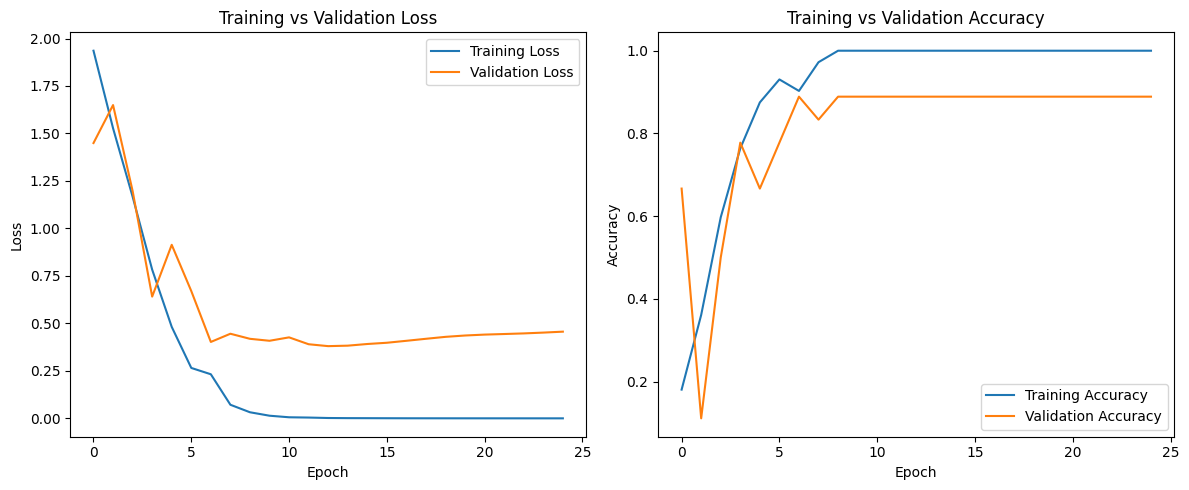

In [12]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 10. Task 5 — Evaluate on the test set

In [13]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 - 0s - 18ms/step - accuracy: 0.5333 - loss: 1.4719
Test Loss: 1.4719
Test Accuracy: 0.5333


## 11. Task 6 — Save and load the model
The worksheet asks for an `.h5` model file.

In [14]:
model.save("fruit_cnn_model.h5")
print("Model saved as fruit_cnn_model.h5")

Model saved as fruit_cnn_model.h5


In [15]:
loaded_model = tf.keras.models.load_model("fruit_cnn_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=2)

print(f"Reloaded Model Loss: {loaded_loss:.4f}")
print(f"Reloaded Model Accuracy: {loaded_acc:.4f}")

2/2 - 0s - 58ms/step - accuracy: 0.5333 - loss: 1.4719
Reloaded Model Loss: 1.4719
Reloaded Model Accuracy: 0.5333


## 12. Task 7 — Predictions and classification report
This generates:
- predicted labels
- true labels
- classification report
- confusion matrix

In [16]:
# Predict probabilities
pred_probs = loaded_model.predict(test_ds, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)

# True labels from dataset
true_labels = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

print("First 10 predicted labels:", pred_labels[:10])
print("First 10 true labels:", true_labels[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
First 10 predicted labels: [1 1 0 0 0 1 2 1 1 1]
First 10 true labels: [0 0 0 0 0 1 1 1 1 1]


In [17]:
print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.44      0.80      0.57         5
    graviola       0.80      0.80      0.80         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.50      0.40      0.44         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.53        30
   macro avg       0.56      0.53      0.53        30
weighted avg       0.56      0.53      0.53        30



In [18]:
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3 2 0 0 0 0]
 [0 4 1 0 0 0]
 [1 0 4 0 0 0]
 [0 1 0 3 0 1]
 [0 0 0 0 2 3]
 [1 2 0 0 2 0]]


## 13. Show some test predictions
This is useful for interpretation.

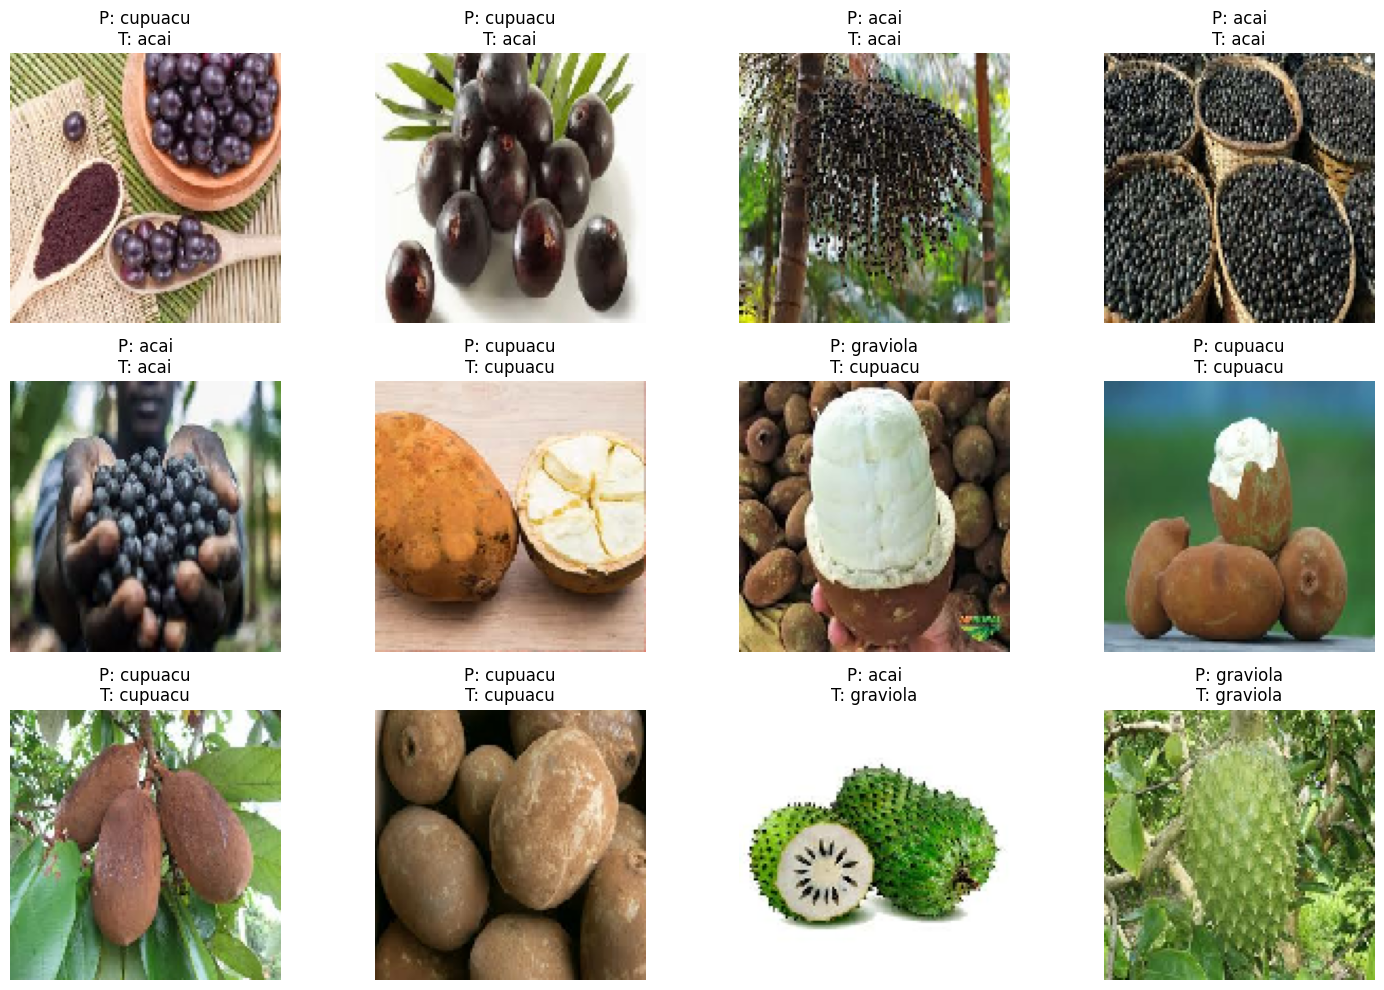

In [19]:
plt.figure(figsize=(15, 10))

for batch_images, batch_labels in test_ds.take(1):
    batch_preds = loaded_model.predict(batch_images, verbose=0)
    batch_pred_labels = np.argmax(batch_preds, axis=1)

    num_show = min(12, len(batch_images))
    for i in range(num_show):
        plt.subplot(3, 4, i + 1)
        plt.imshow(batch_images[i].numpy())
        plt.title(f"P: {class_names[batch_pred_labels[i]]}\nT: {class_names[batch_labels[i].numpy()]}")
        plt.axis("off")

plt.tight_layout()
plt.show()